# Pipeline A — Step 3: Decision Support (Huber FD, 2026 Forecast)

Retrain Huber FD model on ALL data (2022-2025), forecast 2026 under 3 scenarios.

**Estimator:** HuberRegressor (robust terhadap outlier NTB/DKI Jakarta)

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / 'pipeline_A' / 'output' / 'A1_annual_panel.csv').exists(): ROOT = p; break

out = ROOT / 'pipeline_A' / 'output'
df = pd.read_csv(out / 'A1_annual_panel.csv')
df = df.sort_values(['provinsi_id','tahun']).reset_index(drop=True)
df['x5_internet'] = df.groupby('provinsi_id')['x5_internet'].transform(lambda s: s.bfill())
print(f'Loaded: {len(df)} rows, {df["provinsi_id"].nunique()} provinces')

Loaded: 124 rows, 31 provinces


In [2]:
# === Build First-Differences from ALL data ===
econ_cols = ['x1_bi_rate_avg','x2_inflasi_avg','log_pdrb',
             'x4_tpt','x5_internet','x8_ldr','x9_npl','x10_umkm']

frames = []
for pid, g in df.groupby('provinsi_id'):
    g = g.sort_values('tahun')
    d = pd.DataFrame({
        'provinsi_id': g['provinsi_id'].iloc[1:].values,
        'nama_provinsi': g['nama_provinsi'].iloc[1:].values,
        'tahun': g['tahun'].iloc[1:].values,
        'y_level': g['twp90_avg'].iloc[1:].values,
        'y_prev': g['twp90_avg'].iloc[:-1].values,
    })
    d['dy'] = d['y_level'] - d['y_prev']
    for c in econ_cols:
        d[f'd_{c}'] = g[c].iloc[1:].values - g[c].iloc[:-1].values
    frames.append(d)

df_fd = pd.concat(frames, ignore_index=True).dropna().reset_index(drop=True)
dx_cols = [f'd_{c}' for c in econ_cols]

# Fit Huber on ALL diffs
X_all = df_fd[dx_cols].astype(float).values
y_all = df_fd['dy'].astype(float).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

model = HuberRegressor(epsilon=1.35, max_iter=500)
model.fit(X_scaled, y_all)
print(f'Huber trained on {len(X_all)} obs, {len(dx_cols)} features')
print(f'Outlier fraction: {model.outliers_.mean()*100:.1f}%')

Huber trained on 93 obs, 8 features
Outlier fraction: 38.7%


In [3]:
# === 2025 actuals (anchor for 2026) ===
latest = df[df['tahun']==2025][['provinsi_id','nama_provinsi','twp90_avg'] + econ_cols].copy()
latest = latest.rename(columns={'twp90_avg': 'twp90_2025'}).reset_index(drop=True)
n_prov = len(latest)

# === 3 Scenarios ===
scenarios = {
    'Baseline': {c: 0.0 for c in econ_cols},
    'Stress_NPL_Up': {
        'x1_bi_rate_avg': 0.5, 'x2_inflasi_avg': 0.005,
        'log_pdrb': 0.02, 'x4_tpt': 0.3, 'x5_internet': 0.01,
        'x8_ldr': -0.02, 'x9_npl': 0.01, 'x10_umkm': -0.01
    },
    'Optimistic_Recovery': {
        'x1_bi_rate_avg': -0.5, 'x2_inflasi_avg': -0.003,
        'log_pdrb': 0.05, 'x4_tpt': -0.5, 'x5_internet': 0.02,
        'x8_ldr': 0.03, 'x9_npl': -0.005, 'x10_umkm': 0.01
    }
}

all_forecasts = []
for sname, deltas in scenarios.items():
    row_raw = np.array([[deltas[c] for c in econ_cols]])
    row_scaled = scaler.transform(np.tile(row_raw, (n_prov, 1)))
    dy_pred = model.predict(row_scaled)
    
    fc = latest[['provinsi_id','nama_provinsi','twp90_2025']].copy()
    fc['scenario'] = sname
    fc['delta_pred'] = dy_pred
    fc['twp90_2026_pred'] = (fc['twp90_2025'] + fc['delta_pred']).clip(lower=0)
    fc['pct_change'] = (fc['delta_pred'] / fc['twp90_2025'] * 100).round(2)
    all_forecasts.append(fc)

forecasts = pd.concat(all_forecasts, ignore_index=True)
print(f'Generated {len(forecasts)} forecasts ({n_prov} prov x {len(scenarios)} scenarios)')

Generated 93 forecasts (31 prov x 3 scenarios)


In [4]:
# === Risk Classification ===
baseline_fc = forecasts[forecasts['scenario']=='Baseline'].copy().reset_index(drop=True)
stress_fc = forecasts[forecasts['scenario']=='Stress_NPL_Up'].copy().reset_index(drop=True)

risk_levels = []
for i in range(len(baseline_fc)):
    twp = baseline_fc.loc[i, 'twp90_2025']
    stress_twp = stress_fc.loc[i, 'twp90_2026_pred']
    if twp > 0.03 or stress_twp > 0.04:
        risk_levels.append('HIGH')
    elif twp > 0.02 or stress_twp > 0.03:
        risk_levels.append('MEDIUM')
    else:
        risk_levels.append('LOW')

baseline_fc['risk_level'] = risk_levels
baseline_fc['twp90_stress'] = stress_fc['twp90_2026_pred'].values
baseline_fc['stress_delta_pct'] = ((baseline_fc['twp90_stress'] - baseline_fc['twp90_2025'])
                                    / baseline_fc['twp90_2025'] * 100).round(2)

def recommend(row):
    if row['risk_level'] == 'HIGH':
        return 'Intensifkan pengawasan kredit; batasi ekspansi pinjaman baru; tingkatkan cadangan CKPN'
    elif row['risk_level'] == 'MEDIUM':
        return 'Monitor NPL bulanan; evaluasi kualitas portofolio kredit; siapkan early intervention'
    else:
        return 'Pertahankan kebijakan saat ini; peluang ekspansi kredit UMKM'

baseline_fc['rekomendasi'] = baseline_fc.apply(recommend, axis=1)
baseline_fc = baseline_fc.sort_values('twp90_2025', ascending=False).reset_index(drop=True)

print('Risk distribution:')
print(baseline_fc['risk_level'].value_counts().to_string())
display(baseline_fc[['nama_provinsi','twp90_2025','risk_level','twp90_stress','stress_delta_pct','rekomendasi']].head(10))

Risk distribution:
risk_level
LOW       19
MEDIUM     8
HIGH       4


,nama_provinsi,twp90_2025,risk_level,twp90_stress,stress_delta_pct,rekomendasi
0,Dki Jakarta,0.046683,HIGH,0.044423,-4.84,Intensifkan pengawasan kredit; batasi ekspansi...
1,Nusa Tenggara Barat,0.040408,HIGH,0.038148,-5.59,Intensifkan pengawasan kredit; batasi ekspansi...
2,Jawa Timur,0.034067,HIGH,0.031806,-6.64,Intensifkan pengawasan kredit; batasi ekspansi...
3,Jawa Barat,0.033583,HIGH,0.031323,-6.73,Intensifkan pengawasan kredit; batasi ekspansi...
4,Daerah Istimewa Yogyakarta,0.028625,MEDIUM,0.026365,-7.90,Monitor NPL bulanan; evaluasi kualitas portofo...
5,Sumatera Selatan,0.028517,MEDIUM,0.026256,-7.93,Monitor NPL bulanan; evaluasi kualitas portofo...
6,Jawa Tengah,0.028242,MEDIUM,0.025981,-8.00,Monitor NPL bulanan; evaluasi kualitas portofo...
7,Lampung,0.027750,MEDIUM,0.025490,-8.15,Monitor NPL bulanan; evaluasi kualitas portofo...
8,Sumatera Barat,0.026108,MEDIUM,0.023848,-8.66,Monitor NPL bulanan; evaluasi kualitas portofo...
9,Banten,0.024117,MEDIUM,0.021856,-9.37,Monitor NPL bulanan; evaluasi kualitas portofo...


In [5]:
# === Economic Drivers ===
coef_orig = model.coef_ / scaler.scale_

interpretasi_map = {
    'd_x1_bi_rate_avg': 'Kenaikan BI rate -> penurunan TWP90 (kebijakan moneter ketat)',
    'd_x2_inflasi_avg': 'Kenaikan inflasi -> penurunan TWP90',
    'd_log_pdrb': 'Pertumbuhan PDRB -> kenaikan TWP90',
    'd_x4_tpt': 'Kenaikan pengangguran -> penurunan TWP90',
    'd_x5_internet': 'Peningkatan internet -> kenaikan TWP90',
    'd_x8_ldr': 'Kenaikan LDR -> kenaikan TWP90 (ekspansi kredit)',
    'd_x9_npl': 'Kenaikan NPL -> penurunan TWP90 (pengetatan kredit)',
    'd_x10_umkm': 'Kenaikan rasio UMKM -> penurunan TWP90',
}

drivers = pd.DataFrame({
    'faktor_ekonomi': [c.replace('d_','') for c in dx_cols],
    'koefisien': coef_orig.round(6),
    'abs_importance': np.abs(model.coef_),
    'arah': ['Positif' if v > 0 else 'Negatif' for v in coef_orig],
    'interpretasi': [interpretasi_map.get(c,'') for c in dx_cols]
}).sort_values('abs_importance', ascending=False).drop('abs_importance', axis=1)

display(drivers)

,faktor_ekonomi,koefisien,arah,interpretasi
0,x1_bi_rate_avg,-0.001652,Negatif,Kenaikan BI rate -> penurunan TWP90 (kebijakan...
1,x2_inflasi_avg,-0.105687,Negatif,Kenaikan inflasi -> penurunan TWP90
6,x9_npl,-0.132012,Negatif,Kenaikan NPL -> penurunan TWP90 (pengetatan kr...
4,x5_internet,0.005376,Positif,Peningkatan internet -> kenaikan TWP90
7,x10_umkm,0.007968,Positif,Kenaikan rasio UMKM -> penurunan TWP90
3,x4_tpt,-0.000365,Negatif,Kenaikan pengangguran -> penurunan TWP90
2,log_pdrb,-0.002526,Negatif,Pertumbuhan PDRB -> kenaikan TWP90
5,x8_ldr,0.001181,Positif,Kenaikan LDR -> kenaikan TWP90 (ekspansi kredit)


In [6]:
# === SAVE ALL CSVs ===
risk_dash = baseline_fc[['provinsi_id','nama_provinsi','twp90_2025',
    'risk_level','twp90_stress','stress_delta_pct','rekomendasi']].copy()
risk_dash.columns = ['provinsi_id','nama_provinsi','twp90_aktual_2025',
    'level_risiko','twp90_skenario_stress','perubahan_stress_pct','rekomendasi_kebijakan']
risk_dash.to_csv(out / 'A3_province_risk_dashboard.csv', index=False)

scen_wide = forecasts.pivot_table(
    index=['provinsi_id','nama_provinsi','twp90_2025'],
    columns='scenario', values='twp90_2026_pred'
).reset_index()
scen_wide.columns.name = None
scen_wide.to_csv(out / 'A3_scenario_comparison.csv', index=False)

drivers.to_csv(out / 'A3_economic_drivers.csv', index=False)
forecasts.to_csv(out / 'A3_full_forecasts.csv', index=False)

sig_names = 'NPL, Inflasi (top Huber importance)'
pd.DataFrame([{
    'model': 'First-Differences Huber Regressor',
    'training_period': '2023-2025 annual diffs (all data)',
    'n_observations': len(X_all),
    'n_parameters': len(dx_cols) + 1,
    'outlier_fraction': f'{model.outliers_.mean()*100:.1f}%',
    'key_drivers': sig_names,
    'caveat': 'Koefisien = asosiasi bukan kausalitas. Gunakan untuk ranking dan arah, bukan target numerik presisi.'
}]).to_csv(out / 'A3_model_metadata.csv', index=False)

for f in sorted(out.glob('A3_*.csv')):
    print(f'  {f.name} ({f.stat().st_size:,} bytes)')

  A3_economic_drivers.csv (627 bytes)
  A3_full_forecasts.csv (9,094 bytes)
  A3_model_metadata.csv (308 bytes)
  A3_province_risk_dashboard.csv (4,361 bytes)
  A3_scenario_comparison.csv (3,058 bytes)


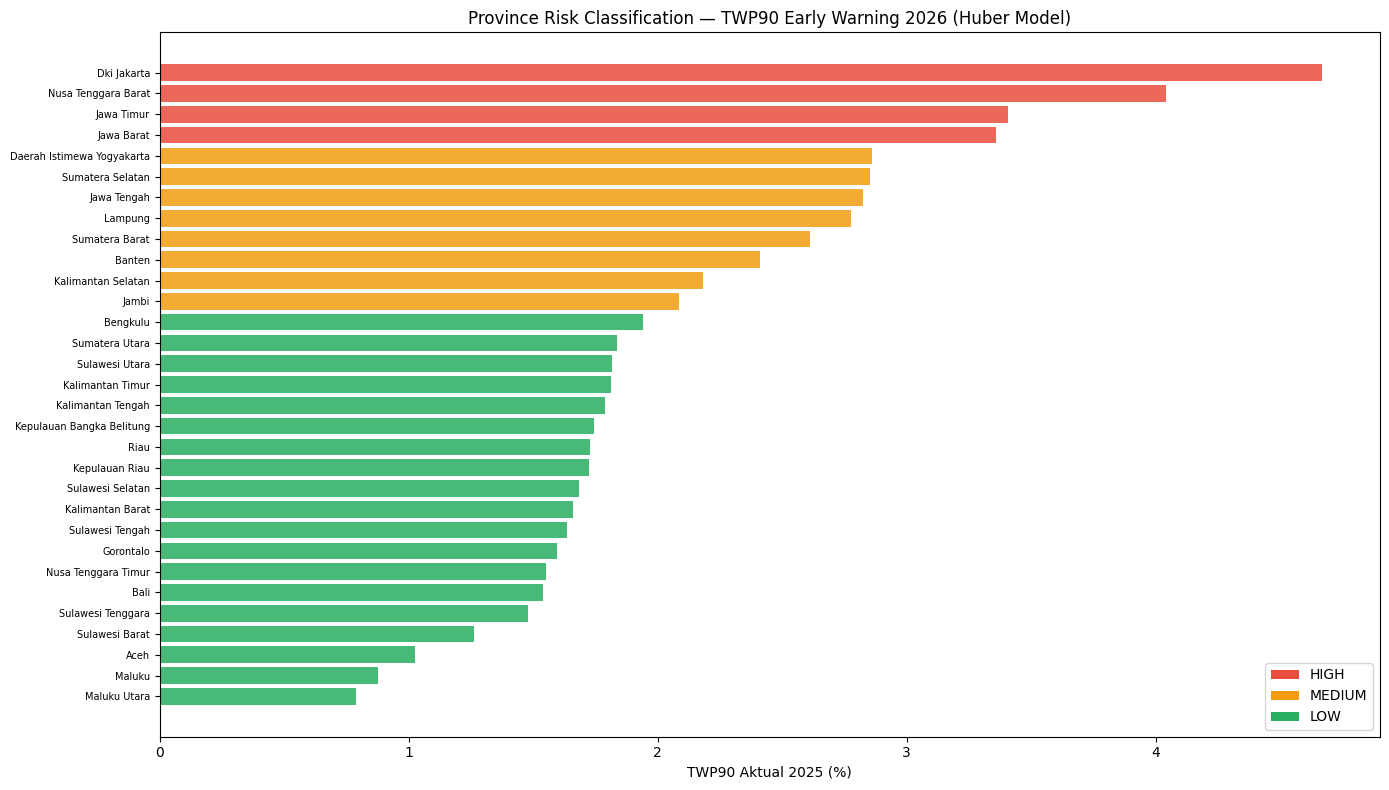

In [7]:
# === VIZ 1: Risk Classification ===
risk_colors = {'HIGH': '#e74c3c', 'MEDIUM': '#f39c12', 'LOW': '#27ae60'}
rd = risk_dash.sort_values('twp90_aktual_2025', ascending=True)

fig, ax = plt.subplots(figsize=(14, 8))
colors = [risk_colors[r] for r in rd['level_risiko']]
ax.barh(range(len(rd)), rd['twp90_aktual_2025']*100, color=colors, alpha=0.85)
ax.set_yticks(range(len(rd)))
ax.set_yticklabels(rd['nama_provinsi'], fontsize=7)
ax.set_xlabel('TWP90 Aktual 2025 (%)')
ax.set_title('Province Risk Classification — TWP90 Early Warning 2026 (Huber Model)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=risk_colors[r], label=r) for r in ['HIGH','MEDIUM','LOW']], loc='lower right')
fig.tight_layout()
fig.savefig(out / 'A3_risk_classification.png', dpi=150, bbox_inches='tight')
plt.show()

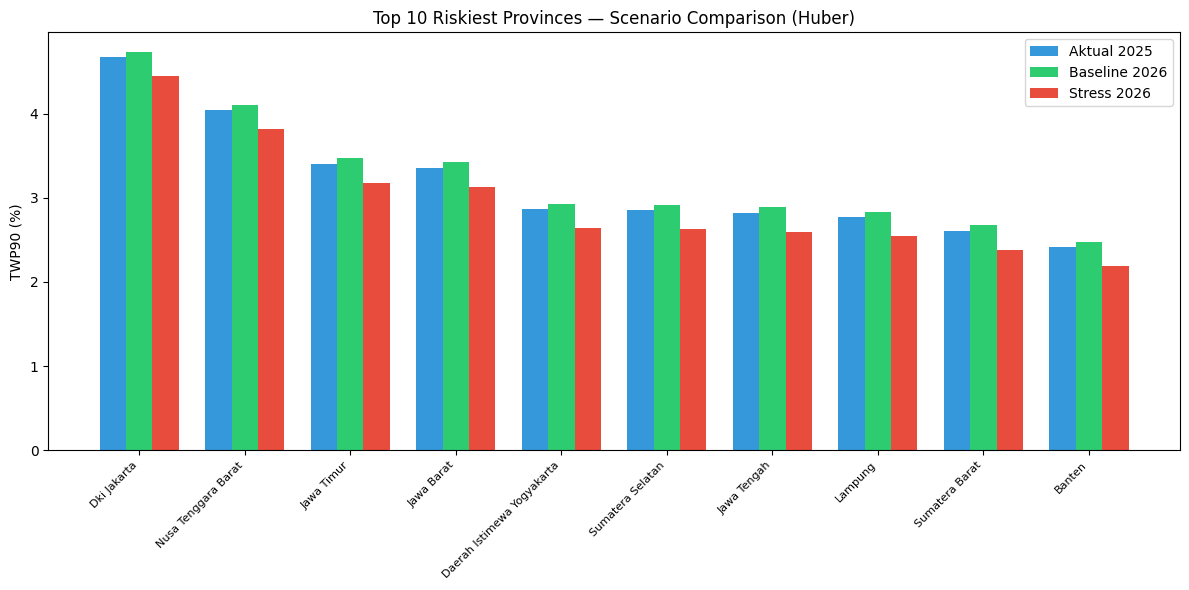

In [8]:
# === VIZ 2: Scenario Top 10 ===
top10 = scen_wide.nlargest(10, 'Stress_NPL_Up')
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top10)); w = 0.25
ax.bar(x - w, top10['twp90_2025']*100, w, label='Aktual 2025', color='#3498db')
ax.bar(x,     top10['Baseline']*100,    w, label='Baseline 2026', color='#2ecc71')
ax.bar(x + w, top10['Stress_NPL_Up']*100, w, label='Stress 2026', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(top10['nama_provinsi'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('TWP90 (%)')
ax.set_title('Top 10 Riskiest Provinces — Scenario Comparison (Huber)')
ax.legend(); fig.tight_layout()
fig.savefig(out / 'A3_scenario_top10.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print('='*70)
print('PIPELINE A - DECISION SUPPORT (HUBER) COMPLETE')
print('='*70)
for lvl in ['HIGH','MEDIUM','LOW']:
    n = (risk_dash['level_risiko']==lvl).sum()
    provs = risk_dash[risk_dash['level_risiko']==lvl]['nama_provinsi'].tolist()
    print(f'{lvl}: {n} provinces - {", ".join(provs[:5])}{"..." if len(provs)>5 else ""}')
print(f'\nEstimator: HuberRegressor (robust, epsilon=1.35)')
print(f'Outlier fraction in training: {model.outliers_.mean()*100:.1f}%')
print(f'Dashboard files: {len(list(out.glob("A3_*")))} outputs')

PIPELINE A - DECISION SUPPORT (HUBER) COMPLETE
HIGH: 4 provinces - Dki Jakarta, Nusa Tenggara Barat, Jawa Timur, Jawa Barat
MEDIUM: 8 provinces - Daerah Istimewa Yogyakarta, Sumatera Selatan, Jawa Tengah, Lampung, Sumatera Barat...
LOW: 19 provinces - Bengkulu, Sumatera Utara, Sulawesi Utara, Kalimantan Timur, Kalimantan Tengah...

Estimator: HuberRegressor (robust, epsilon=1.35)
Outlier fraction in training: 38.7%
Dashboard files: 7 outputs
